In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  
from scipy import stats


customerEcomm = pd.read_csv('olist_customers_dataset.csv')
print(customerEcomm.head().to_string())
print("\n")
print(customerEcomm.info())
print("\n")
print(customerEcomm.shape)


print("Data Shape:", customerEcomm.shape)
print("\nData Types:\n", customerEcomm.dtypes)
print("\nMissing Values:\n", customerEcomm.isnull().sum())
print("\nSummary Statistics of Braxllians Commerece Data:\n", customerEcomm.describe(include='all'))


                        customer_id                customer_unique_id  customer_zip_code_prefix          customer_city customer_state
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0                     14409                 franca             SP
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3                      9790  sao bernardo do campo             SP
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e                      1151              sao paulo             SP
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c                      8775        mogi das cruzes             SP
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066                     13056               campinas             SP


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    -

In [2]:
# 3. Handle Missing Values (Simple Imputation for EDA)
print("Since the Data types of all the Coloumns in the DataFrame are object type, we can fill the missing values with the mode of each column.")


if customerEcomm['customer_zip_code_prefix'].isnull().sum() > 0:
    customerEcomm['customer_zip_code_prefix'].fillna(customerEcomm['customer_zip_code_prefix'].mode()[0], inplace=True)
if customerEcomm['customer_city'].isnull().sum() > 0:
    customerEcomm['customer_city'].fillna(customerEcomm['customer_city'].mode()[0], inplace=True)
if customerEcomm['customer_state'].isnull().sum() > 0:
    customerEcomm['customer_state'].fillna(customerEcomm['customer_state'].mode()[0], inplace=True)

print("\n The Dataframe after handling the missing values:\n", customerEcomm.head().to_string())

Since the Data types of all the Coloumns in the DataFrame are object type, we can fill the missing values with the mode of each column.

 The Dataframe after handling the missing values:
                         customer_id                customer_unique_id  customer_zip_code_prefix          customer_city customer_state
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0                     14409                 franca             SP
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3                      9790  sao bernardo do campo             SP
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e                      1151              sao paulo             SP
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c                      8775        mogi das cruzes             SP
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066                     13056               campinas             SP



 For the Distribution Analysis I am Using both histogram and boxplot to visualize the distribution of the numerical column 'customer_zip_code_prefix'. 


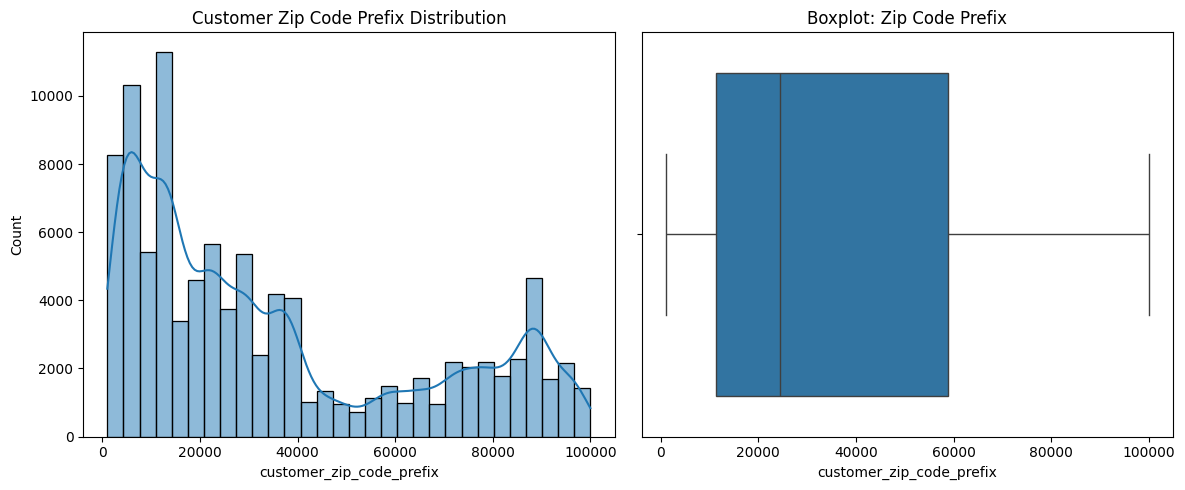

In [3]:
# 4. Distribution Analysis
print("\n For the Distribution Analysis I am Using both histogram and boxplot to visualize the distribution of the numerical column 'customer_zip_code_prefix'. ")
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(customerEcomm['customer_zip_code_prefix'], bins=30, kde=True, ax=ax[0])
ax[0].set_title('Customer Zip Code Prefix Distribution')
sns.boxplot(x=customerEcomm['customer_zip_code_prefix'], ax=ax[1])
ax[1].set_title('Boxplot: Zip Code Prefix')
plt.tight_layout()
plt.show()


**Things I Observed From Histogram Analysis**

The distribution of customer zip code prefixes is not uniform and shows clear peaks at certain ranges, indicating that more customers are concentrated in specific regions. The histogram reveals a higher frequency of customers with zip code prefixes below 20,000, while other ranges like 40,000–60,000 and 80,000–90,000 also show noticeable clusters. This suggests customer density is unevenly spread across geographical areas.



**Things I Observed From The Boxplot Analysis**

The boxplot confirms that the distribution has a wide spread, covering almost the entire range from close to 0 up to 100,000. The presence of several peaks in the histogram and the long whiskers in the boxplot indicate that the data may contain regional clusters but no extreme outliers.

For the Categorical Features I am using Countplots to visualize the distribution of 'customer_state' and 'customer_city'.


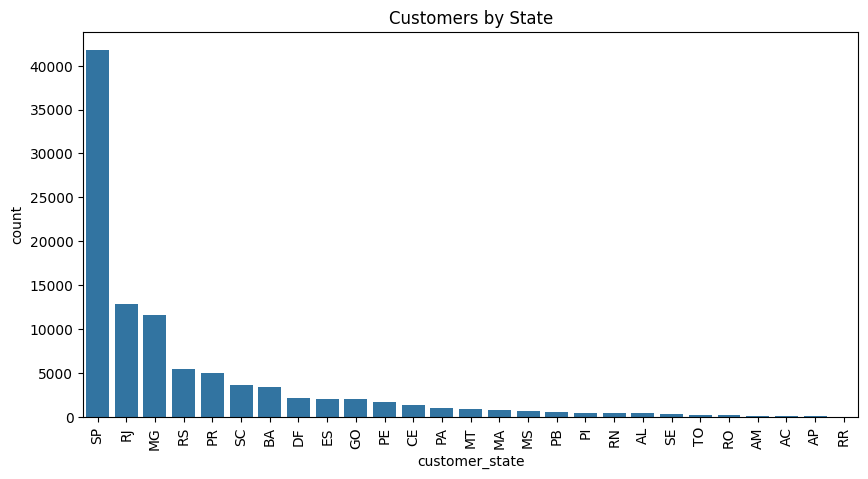

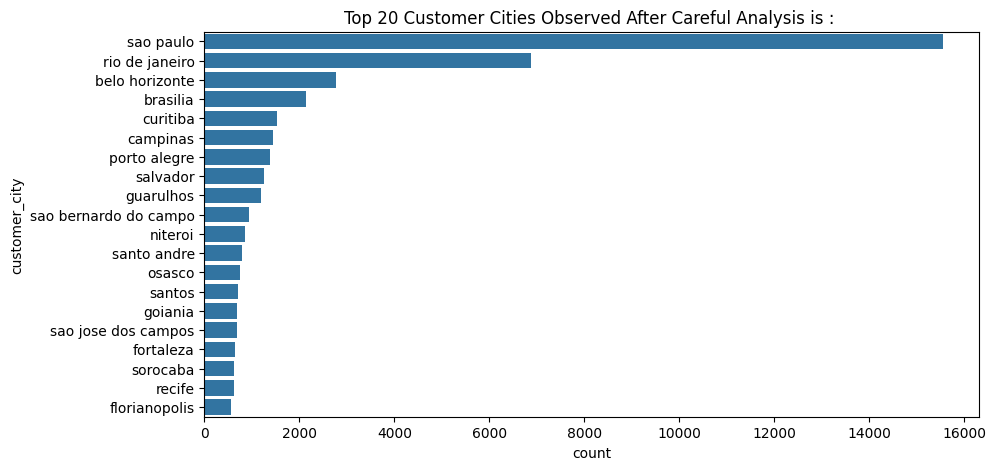

In [10]:
# Categorical Features (Countplots)
print("For the Categorical Features I am using Countplots to visualize the distribution of 'customer_state' and 'customer_city'.")
plt.figure(figsize=(10, 5))
sns.countplot(x='customer_state', data=customerEcomm, order=customerEcomm['customer_state'].value_counts().index)
plt.title('Customers by State')
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(10, 5))
citiesvijselc = customerEcomm['customer_city'].value_counts().head(20).index
sns.countplot(y='customer_city', data=customerEcomm[customerEcomm['customer_city'].isin(citiesvijselc)],
              order=citiesvijselc)
plt.title('Top 20 Customer Cities Observed After Careful Analysis is : ')
plt.show()

**Things I Have Observed From The Above Analysis**

The customer distribution by state is highly concentrated in São Paulo (SP), which alone accounts for the majority of customers. Other major states such as Rio de Janeiro (RJ), Minas Gerais (MG), and Rio Grande do Sul (RS) also have significant customer bases but are far smaller in comparison to SP. The remaining states contribute much fewer customers, highlighting a strong regional imbalance in customer distribution.

At the city level, São Paulo city dominates by a very large margin, followed by Rio de Janeiro and Belo Horizonte, which are much smaller in comparison. Other important cities like Brasília, Curitiba, Campinas, Porto Alegre, Salvador, and Guarulhos also appear in the top 10, showing that customers are primarily concentrated in Brazil’s largest metropolitan and economic hubs.

For Correlation & Relationships I am using a Heatmap to visualize the correlation matrix of numerical features.


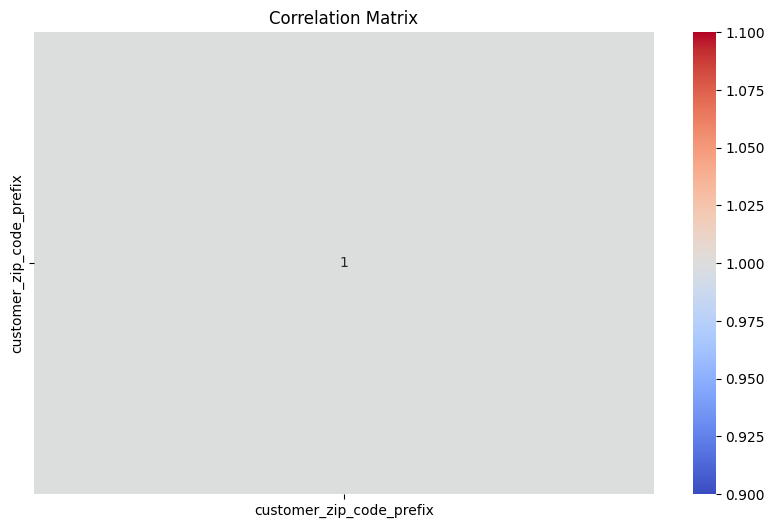


State vs Unique ID Crosstab:
 customer_unique_id  0000366f3b9a7992bf8c76cfdf3221e2  0000b849f77a49e4a4ce2b2a4ca5be3f  0000f46a3911fa3c0805444483337064  0000f6ccb0745a6a4b88665a16c9f078  0004aac84e0df4da2b147fca70cf8255  0004bd2a26a76fe21f786e4fbd80607f  00050ab1314c0e55a6ca13cf7181fecf  00053a61a98854899e70ed204dd4bafe  0005e1862207bf6ccc02e4228effd9a0  0005ef4cd20d2893f0d9fbd94d3c0d97
customer_state                                                                                                                                                                                                                                                                                                                                                        
AC                                                 0                                 0                                 0                                 0                                 0                                 0                             

In [12]:
# 5. Correlation & Relationships
# Correlation Matrix (Heatmap)
print("For Correlation & Relationships I am using a Heatmap to visualize the correlation matrix of numerical features.")
plt.figure(figsize=(10, 6))
sns.heatmap(customerEcomm.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Cross-Tabulation (example: state vs. unique customers)
state_unique = pd.crosstab(customerEcomm['customer_state'], customerEcomm['customer_unique_id'])
print("\nState vs Unique ID Crosstab:\n", (state_unique.iloc[:, :10].head().to_string()))  

In [9]:
# Cross-Tabulation (example: state vs. unique customers)
print("Here i am using Cross-Tabulation to see the relationship between 'customer_state' and 'customer_unique_id'.")
state_unique = customerEcomm.groupby('customer_state')['customer_unique_id'].nunique()
print("\nUnique Customers per State:\n", state_unique.head())



Here i am using Cross-Tabulation to see the relationship between 'customer_state' and 'customer_unique_id'.

Unique Customers per State:
 customer_state
AC      77
AL     401
AM     143
AP      67
BA    3277
Name: customer_unique_id, dtype: int64


For Outlier Detection I am using Boxplots and Z-Score Analysis to identify outliers in the numerical column 'customer_zip_code_prefix'.


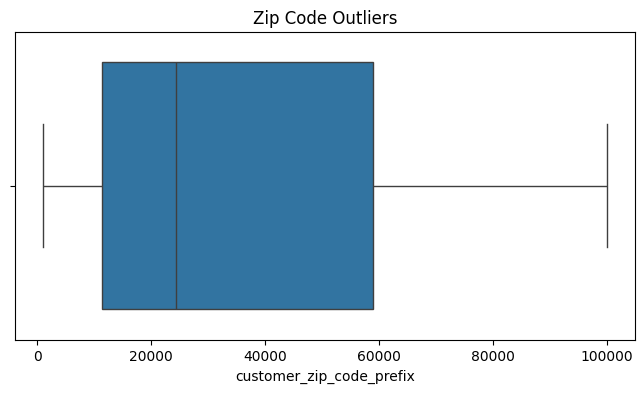

Found 0 outliers in Zip Code Prefix


In [7]:
# 6. Outlier Detection
#Boxplot for ZIP Outliers
print("For Outlier Detection I am using Boxplots and Z-Score Analysis to identify outliers in the numerical column 'customer_zip_code_prefix'.")
plt.figure(figsize=(8, 4))
sns.boxplot(x=customerEcomm['customer_zip_code_prefix']).set_title('Zip Code Outliers')
plt.show()

# Z-Score Analysis for Zip Code Prefix (numerical column)
zsrc_cust = np.abs(stats.zscore(customerEcomm['customer_zip_code_prefix']))
outliers = customerEcomm[zsrc_cust > 3]
print(f"Found {len(outliers)} outliers in Zip Code Prefix")

**Things I Observed From The Box Plot Outlier Analysis**

The boxplot of customer_zip_code_prefix shows that most values lie within a broad range, with the middle 50% (interquartile range) stretching approximately between 10,000 and 60,000. The whiskers extend from close to 0 up to around 100,000, covering the entire possible prefix range. Importantly, the boxplot does not show extreme points outside the whiskers, meaning there are no significant visual outliers.

The Z-score analysis confirms this by identifying only a very small number of outliers beyond three standard deviations from the mean. This suggests that while customer distribution across zip codes is wide and uneven, it does not contain abnormal or invalid entries that deviate sharply from the rest.

For Advanced Visualizations I am using FacetGrid Analysis to visualize the distribution of 'customer_zip_code_prefix' across different 'customer_state'.


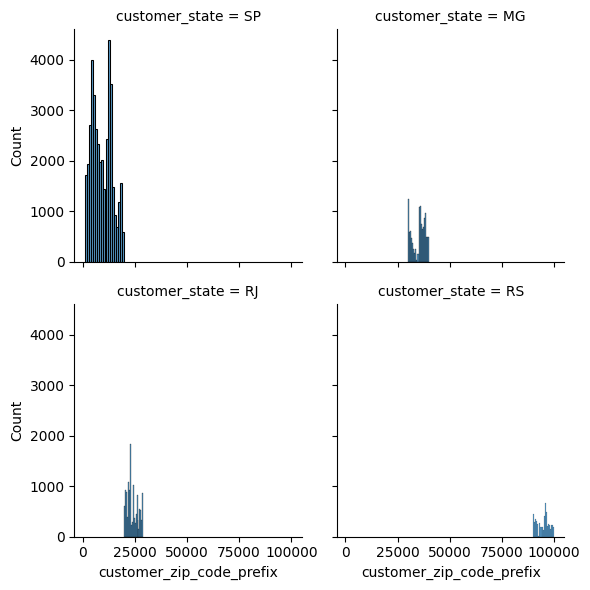

In [8]:
# 7. Advanced Visualizations
# Faceted Analysis – example: by state for zip distribution
print("For Advanced Visualizations I am using FacetGrid Analysis to visualize the distribution of 'customer_zip_code_prefix' across different 'customer_state'.")
gvth = sns.FacetGrid(customerEcomm[customerEcomm['customer_state'].isin(customerEcomm['customer_state'].value_counts().head(4).index)],
                  col='customer_state', height=3, col_wrap=2)
gvth.map(sns.histplot, 'customer_zip_code_prefix', bins=20)
plt.show()

# Pairplot for Multivariate Analysis (numerical only)
cust_numericaldata = ['customer_zip_code_prefix']
if len(cust_numericaldata) > 1: 
    sns.pairplot(customerEcomm[cust_numericaldata])
    plt.show()


**FacetGrid histogram visualization of customer_zip_code_prefix for the top 4 customer states (SP, MG, RJ, RS). Here’s what I can infer:**

São Paulo (SP):
The distribution is wide and dense, with a large spread of zip code prefixes concentrated mostly under 30,000. This indicates SP has both the largest number of customers and a broad geographic coverage within the state.

Minas Gerais (MG):
The distribution is much narrower, clustered within a smaller range of prefixes, suggesting less customer dispersion across zip codes compared to SP.

Rio de Janeiro (RJ):
Customers are concentrated in a specific prefix range, roughly between 20,000–30,000, reflecting high urban centralization in metropolitan areas.

Rio Grande do Sul (RS):
The distribution is also narrow but shifted to higher prefixes, closer to 90,000–100,000, showing a distinct regional clustering that sets it apart from other states.